# Regressions

## Linear regressions

## Part 1: Income and education

**Import the Duncan/carData dataset**

In [38]:
# Import statsmodels and load the Duncan dataset
import statsmodels.api as sm
dataset = sm.datasets.get_rdataset("Duncan", "carData", cache=True)
df = dataset.data
df.head()  
df.info()  

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, accountant to waiter
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   type       45 non-null     object
 1   income     45 non-null     int64 
 2   education  45 non-null     int64 
 3   prestige   45 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.8+ KB


In [39]:
# Summary statistics
df.describe()

,income,education,prestige
count,45.000000,45.000000,45.000000
mean,41.866667,52.555556,47.688889
std,24.435072,29.760831,31.510332
min,7.000000,7.000000,3.000000
25%,21.000000,26.000000,16.000000
50%,42.000000,45.000000,41.000000
75%,64.000000,84.000000,81.000000
max,81.000000,100.000000,97.000000


**Estimate by hand the model $\text{income} = \alpha + \beta \times \text{education}$. Plot.**

## OLS Reminder

Linear model: $y_i = \alpha + \beta x_i + \varepsilon_i$

**Formulas:**  
Slope: $\beta = \frac{Cov(y,x)}{Var(x)}$  
Intercept: $\alpha = \bar y - \beta \bar x$  
Prediction: $\hat y_i = \alpha + \beta x_i$

Manual calculation for demonstration (libraries handle this automatically):

In [40]:
# Covariance matrix for OLS formula
Σ = df[['income', 'education']].cov()
Σ

,income,education
income,597.072727,526.871212
education,526.871212,885.707071


In [41]:
# Sample means
μ = df[['income', 'education']].mean()
μ

income       41.866667
education    52.555556
dtype: float64

In [42]:
# Slope coefficient β = Cov(y,x) / Var(x)
β = Σ.loc['income','education'] / Σ.loc['education','education']
β

np.float64(0.5948594400410561)

In [43]:
# Intercept α = mean(y) - β * mean(x)
α = μ['income'] - β*μ['education']
α

np.float64(10.603498317842273)

In [44]:
# Predicted values: ŷ = α + β * education
prediction = α + β*df['education']

Text(0, 0.5, 'Income')

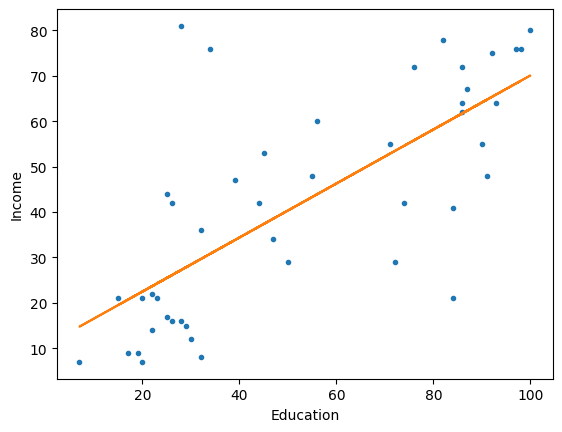

In [45]:
# Plot regression
from matplotlib import pyplot as plt
plt.plot(df['education'], df['income'], '.')  
plt.plot(df['education'], prediction)  
plt.xlabel('Education')  
plt.ylabel('Income')  

**Compute total, explained, unexplained variance. Compute R² statistics**

## Variance Decomposition & $R^2$

$y$ = actual, $\hat y$ = predicted, $e_i = y_i - \hat y_i$ = residual

**Decomposition:**  
$TSS = \sum_i (y_i - \bar y)^2$, $ESS = \sum_i (\hat y_i - \bar y)^2$, $RSS = \sum_i e_i^2$  
$TSS = ESS + RSS$

**Goodness of Fit:** $R^2 = \frac{ESS}{TSS} = 1 - \frac{RSS}{TSS}$

Manual calculation to verify formulas:

In [46]:
# Store fitted values and residuals
df['prediction'] = α + β*df['education']
df['residual'] = df['income'] - df['prediction']

In [47]:
# Covariance matrix for variance decomposition
Sigma = df[['income', 'education', 'prediction', 'residual']].cov()

In [48]:
# Variance components
total_variance = Sigma.loc['income', 'income']            # TSS/n
prediction_variance = Sigma.loc['prediction', 'prediction']  # ESS/n  
residual_variance = Sigma.loc['residual', 'residual']        # RSS/n

In [49]:
print(f"Total variance: {total_variance:.2f}")
print(f"Explained variance: {prediction_variance:.2f}")
print(f"Residual variance: {residual_variance:.2f}")
print(f"Sum check: {prediction_variance + residual_variance:.2f}")

# R² calculation
myRsquared = 1 - residual_variance / total_variance
print(f"R²: {myRsquared:.2f}")

Total variance: 597.07
Explained variance: 313.41
Residual variance: 283.66
Sum check: 597.07
R²: 0.52


**Use statsmodels to estimate $\text{income} = \alpha + \beta \times \text{education}$. Comment regression statistics.**

In [50]:
# OLS with statsmodels formula API
import statsmodels.formula.api as smf

model_1 = smf.ols("income ~ education", data=df)  
res_1 = model_1.fit()  

In [51]:
print(res_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     47.51
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           1.84e-08
Time:                        12:07:15   Log-Likelihood:                -190.42
No. Observations:                  45   AIC:                             384.8
Df Residuals:                      43   BIC:                             388.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.6035      5.198      2.040      0.0

**Estimated equation:** $\widehat{income} = 10.6 + 0.59 \times education$

• Each additional year of education increases income by 0.59 units on average  
• Both coefficients significant (p < 0.05)  
• $R^2 = 0.52$ → education explains 52% of income variation

**Use statsmodels to estimate $\text{income} = \alpha + \beta \times \text{prestige}$. Comment regression statistics.**

In [52]:
# Regression with prestige as predictor
model_2 = smf.ols("income ~ prestige", df)
res_2 = model_2.fit()

In [53]:
print(res_2.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     101.3
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           7.14e-13
Time:                        12:07:17   Log-Likelihood:                -179.93
No. Observations:                  45   AIC:                             363.9
Df Residuals:                      43   BIC:                             367.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.8840      3.678      2.959      0.0

**Estimated equation:** $\widehat{income} = 10.88 + 0.65 \times prestige$

• One-unit increase in prestige increases income by 0.65 units on average  
• Both coefficients significant (p < 0.01)  
• $R^2 = 0.70$ → prestige explains 70% of income variation

**Use statsmodels to estimate $\text{income} = \alpha + \beta \times \text{education} + \beta_2 \times \text{prestige}$. Comment regression statistics.**

In [54]:
# Multiple regression with education and prestige
model_3 = smf.ols("income ~ education + prestige", df)
res_3 = model_3.fit()

In [55]:
print(res_3.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     49.55
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           8.88e-12
Time:                        12:07:18   Log-Likelihood:                -179.90
No. Observations:                  45   AIC:                             365.8
Df Residuals:                      42   BIC:                             371.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.4264      4.164      2.504      0.0

**Estimated equation:** $\widehat{income} = 10.43 + 0.03 \times education + 0.62 \times prestige$

• Education coefficient insignificant (p = 0.81) when controlling for prestige  
• Prestige remains strongly significant  
• $R^2 = 0.70$ but adjusted $R^2$ drops → education adds no predictive power

Education and prestige likely correlated. Check multicollinearity:

In [56]:
# Check correlation between predictors
df[['prestige','education']].corr()

,prestige,education
prestige,1.000000,0.851916
education,0.851916,1.000000


Strong correlation (≈ 0.85) confirms multicollinearity. When both variables contain similar information, standard errors increase and coefficients become unstable.

**Which model would you recommend? For which purpose?**

• **Prediction:** prestige-only model (highest $R^2$)  
• **Education effect:** education-only model (avoids multicollinearity)

**Plot the regression with prestige**

In [57]:
# Extract prestige for plotting
x = df['prestige']

In [58]:
# Calculate fitted values from coefficients  
a = res_2.params.Intercept
b = res_2.params.prestige
y = a + b*x

In [59]:
# Alternative: use predict method
y = res_2.predict(x)

Text(0, 0.5, 'Income')

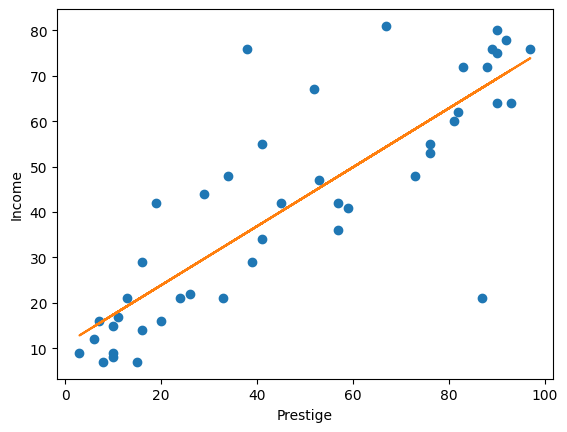

In [60]:
# Plot regression
from matplotlib import pyplot as plt
plt.plot(x, df['income'], 'o')  
plt.plot(x, y)  
plt.xlabel("Prestige")  
plt.ylabel("Income")  

Linear relationship appears reasonable, but good visual fit ≠ causal interpretation.

**Check visually normality of residuals**

In [61]:
# Calculate residuals for diagnostics
pred = a + b*x
actual = df['income']
resid = actual - pred

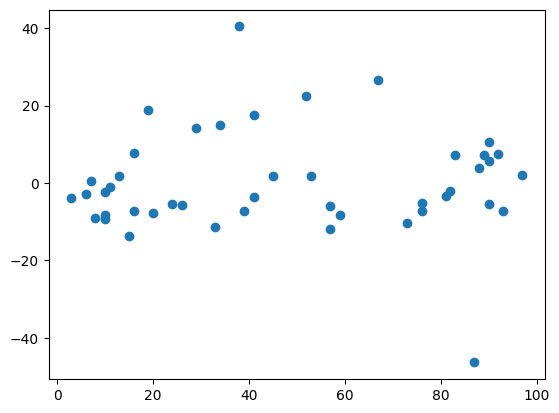

In [62]:
# Residuals vs fitted plot (checks homoscedasticity)
plt.plot(x, resid, 'o')

Residuals not perfectly random around zero → model may miss relevant variables.  
If omitted variables correlate with prestige, coefficient may be biased.

(array([ 1.,  0.,  0.,  2., 19., 11.,  6.,  4.,  1.,  1.]),
 array([-46.40643935, -37.72299114, -29.03954294, -20.35609473,
        -11.67264653,  -2.98919832,   5.69424989,  14.37769809,
         23.0611463 ,  31.74459451,  40.42804271]),
 <BarContainer object of 10 artists>)

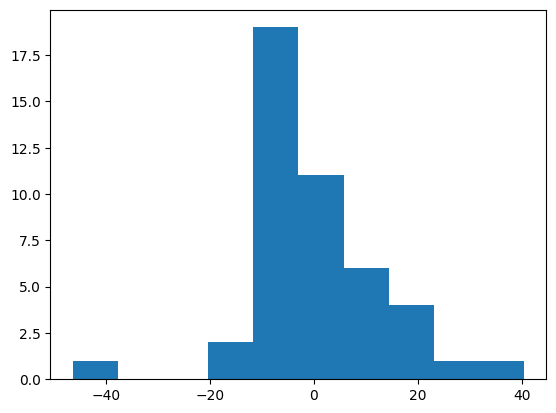

In [63]:
# Histogram of residuals (checks normality)
plt.hist(resid)

OLS estimates show associations in data, not necessarily causal effects.  
Next week: instrumental variables to recover causal effects when regressors correlate with unobserved factors.

## Part 2: Taylor Rule

In 1993, John taylor, estimated, using US data the regression: $i_t = i^{\star} + \alpha_{\pi} \pi_t + \alpha_{\pi} y_t$ where $\pi_t$ is inflation and $y_t$ the output gap (let's say deviation from real gdp from the trend).
He found that both coefficients were not significantly different from $0.5$.
Our goal, is to replicate the same analysis.

In very simple terms, Taylor was trying to see how a central bank behaves in practice. The idea is intuitive: when inflation rises, the central bank should raise interest rates to cool the economy, and when the economy is booming (output above its normal level), it should also raise rates to prevent overheating. By estimating this regression with real data, we are checking whether actual policy decisions followed this common-sense stabilizing rule rather than being random or discretionary

**Import macro data from statsmodels**

In [64]:
# Import statsmodels to access built-in datasets including macroeconomic data
import statsmodels

# Import statsmodels API for regression analysis
import statsmodels.api as sm

In [65]:
# Load quarterly US macroeconomic data
ds = sm.datasets.macrodata.load_pandas()

In [66]:
# Extract raw data from dataset object and preview
df = ds.raw_data
df.head()  # Display first 5 rows

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


**Create database with variables of interest including detrended GDP**

In [67]:
# Extract key variables needed for Taylor Rule regression
gdp = df['realgdp']  # Real GDP
inflation = df['infl']  # Inflation rate
realint = df['realint']  # Real interest rate

In [68]:
# Copy dataframe for analysis (will add computed variables like interest rate and output gap)
ddf = df

In [69]:
# Preview the dataframe structure and contents
ddf.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


Fisher relation: $r_t = i_t - \pi_t$

In [70]:
# Nominal interest rate: i = r + π
ddf['ir'] = ddf['realint'] + ddf['infl']

Detrend GDP using HP-filter (classical macroeconomic tool):

In [71]:
# Import Hodrick-Prescott filter for trend-cycle decomposition
# HP filter is a classical tool in macroeconomics to extract business cycles
from statsmodels.tsa.filters.hp_filter import hpfilter

In [72]:
# Apply HP filter to decompose GDP into trend and cyclical components
# cycle = deviations from trend (business cycle), trend = long-run path
cycle, trend = hpfilter(ddf['realgdp'])

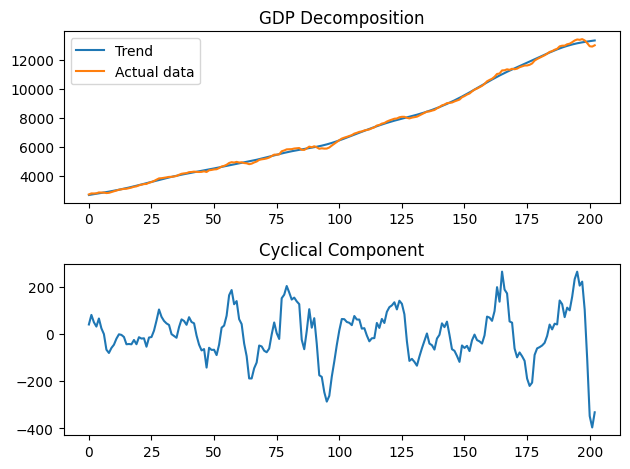

In [73]:
# Visualize trend-cycle decomposition of GDP
# Upper plot: trend line vs actual data; Lower plot: cyclical component alone
plt.subplot(211)
plt.plot(trend, label='Trend')
plt.plot(trend+cycle, label='Actual data')
plt.title("GDP Decomposition")
plt.legend(loc='upper left')
plt.subplot(212)
plt.plot(cycle)
plt.title("Cyclical Component")
plt.tight_layout()

In [74]:
# Create output gap variable: (cycle / trend) * 100 as percentage
# Output gap measures deviation of actual GDP from potential GDP
ddf['gdp'] = cycle/trend*100

In [75]:
# Preview updated dataframe with newly computed variables (ir and gdp)
ddf.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,ir,gdp
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,0.00,1.479383
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,3.08,2.967657
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,3.83,1.792534
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,4.33,1.110571
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,3.50,2.331547


**Run the basic regression**

In [76]:
# Import formula API for specifying regressions using R-style notation
from statsmodels.formula import api as sm

In [78]:
# Basic Taylor Rule: interest rate responds to inflation and output gap
# Tests whether policy rate responds to inflation and economic slack
# "-1" suppresses the intercept (alternative specification without constant term)
model = sm.ols("ir ~ infl + gdp - 1", data=ddf)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                     ir   R-squared (uncentered):                   0.757
Model:                            OLS   Adj. R-squared (uncentered):              0.755
Method:                 Least Squares   F-statistic:                              313.1
Date:                Mon, 16 Feb 2026   Prob (F-statistic):                    1.80e-62
Time:                        12:08:39   Log-Likelihood:                         -508.16
No. Observations:                 203   AIC:                                      1020.
Df Residuals:                     201   BIC:                                      1027.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### Interpreting the results

Estimated rule:

$ir = 1.03\,infl - 0.23\,gdp$

- The interest rate reacts strongly and significantly to inflation
- The output gap coefficient is negative and not statistically significant
- The model captures a response to inflation but little systematic reaction to economic activity

The uncentered $R^2$ cannot be compared directly to models with a constant.


**Which control variables would you add? Does it increase prediction power?**

In [79]:
ddf.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,ir,gdp
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,0.00,1.479383
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,3.08,2.967657
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,3.83,1.792534
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,4.33,1.110571
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,3.50,2.331547


In [80]:
# Extended Taylor Rule with control variables (population and unemployment)
# Tests robustness of inflation and output gap coefficients to other factors
# Population (pop) and unemployment (unemp) added as control variables
model = sm.ols("ir ~ infl + gdp + pop + unemp - 1", data=ddf)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                     ir   R-squared (uncentered):                   0.884
Model:                            OLS   Adj. R-squared (uncentered):              0.882
Method:                 Least Squares   F-statistic:                              380.2
Date:                Mon, 16 Feb 2026   Prob (F-statistic):                    5.64e-92
Time:                        12:08:46   Log-Likelihood:                         -432.84
No. Observations:                 203   AIC:                                      873.7
Df Residuals:                     199   BIC:                                      886.9
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In the baseline regression the output gap was negative and not significant.
After adding controls it becomes positive and significant.

This indicates the simple model was misspecified: other macro variables were
capturing part of the variation in the interest rate. Once they are controlled for,
the response to economic activity appears clearly.

The signs now match the Taylor rule: the central bank raises the interest rate
when inflation rises and when the output gap increases (economy above potential).

The 95% confidence intervals for inflation [0.341, 0.535] and GDP [0.333, 0.809]
exclude zero, confirming statistical significance. They also contain values close
to 0.5, consistent with a Taylor-type policy response.
